# Labb 2 – More Statistical Inference and Data Analytics

Data Science & Machine Learning: 7,5 hp 

Gruppnummer: 15

---
## Uppgift 8 – ANOVA: Analys av globala supporttider (ANOVA vs. Kruskal-Wallis)

In [238]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Generera gruppspecifikt dataset 
gruppnummer = 15
rng = np.random.default_rng(gruppnummer)

center = ['Sverige', 'Indien', 'USA']
n_per_group = 50

# Grupp 15 är udda => normalfördelat
dist_type = "skewed" if gruppnummer % 2 == 0 else "normal"

data_list = []
for i, c in enumerate(center):
    loc = 10 + (gruppnummer % 3) + i
    if dist_type == "normal":
        values = rng.normal(loc=loc, scale=2.5, size=n_per_group)
    else:
        values = rng.lognormal(mean=np.log(loc), sigma=0.5, size=n_per_group)
    temp_df = pd.DataFrame({'Center': c, 'Svarstid': values})
    data_list.append(temp_df)

df = pd.concat(data_list).reset_index(drop=True)
print(f"Data genererad för grupp {gruppnummer} (Typ: {dist_type})")
print(df.groupby('Center')['Svarstid'].describe().round(2))

Data genererad för grupp 15 (Typ: normal)
         count   mean   std   min    25%    50%    75%    max
Center                                                       
Indien    50.0  11.37  2.62  6.94   9.31  11.63  13.19  16.44
Sverige   50.0  10.03  2.56  4.30   8.27  10.51  11.80  15.24
USA       50.0  12.38  2.37  5.97  10.70  12.42  13.82  17.32


## Deluppgift 1: Explorativ Dataanalys (EDA)

C:\Users\wisam\AppData\Local\Temp\ipykernel_32092\3877722964.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Center', y='Svarstid', ax=axes[1], palette='Set2')


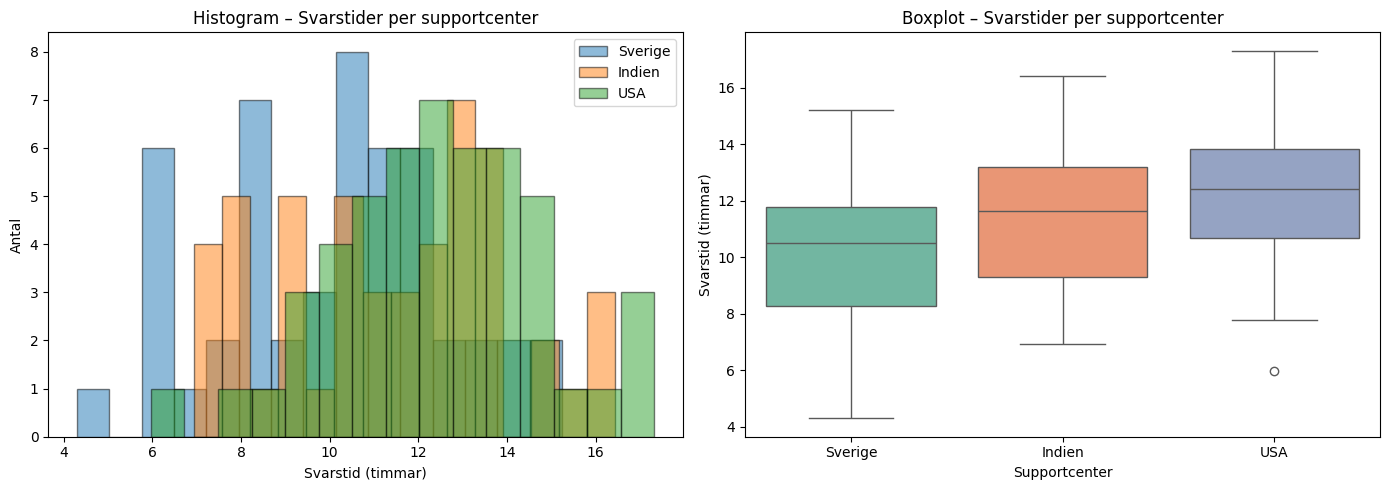

Visuell analys:
- Histogrammen ser approximativt normalfördelade ut för alla tre center.
- Boxplottarna visar liknande spridning (varians) för de tre grupperna.
- USA har ett något högre medelvärde, Sverige lägst.


In [239]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Density / Histogram per center
for c in center:
    grp = df[df['Center'] == c]['Svarstid']
    axes[0].hist(grp, bins=15, alpha=0.5, label=c, edgecolor='black')
axes[0].set_title('Histogram – Svarstider per supportcenter')
axes[0].set_xlabel('Svarstid (timmar)')
axes[0].set_ylabel('Antal')
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x='Center', y='Svarstid', ax=axes[1], palette='Set2')
axes[1].set_title('Boxplot – Svarstider per supportcenter')
axes[1].set_xlabel('Supportcenter')
axes[1].set_ylabel('Svarstid (timmar)')

plt.tight_layout()
plt.show()

print("Visuell analys:")
print("- Histogrammen ser approximativt normalfördelade ut för alla tre center.")
print("- Boxplottarna visar liknande spridning (varians) för de tre grupperna.")
print("- USA har ett något högre medelvärde, Sverige lägst.")

## Deluppgift 2: Test av antaganden – Shapiro-Wilk normalitetstest

In [240]:
print("Shapiro-Wilk normalitetstest per supportcenter:")
print("-" * 50)
alla_normal = True
for c in center:
    grp = df[df['Center'] == c]['Svarstid']
    stat, p = stats.shapiro(grp)
    normalfordeld = "JA" if p > 0.05 else "NEJ"
    print(f"{c}: W={stat:.4f}, p={p:.4f} => Normalfördelad? {normalfordeld}")
    if p <= 0.05:
        alla_normal = False

print()
if alla_normal:
    print("Slutsats: Alla grupper är normalfördelade (p > 0.05 för alla).")
    print("=> Vi går vidare med One-way ANOVA.")
else:
    print("Slutsats: Minst en grupp avviker från normalfördelning.")
    print("=> Vi provar logtransformation och/eller Kruskal-Wallis.")

Shapiro-Wilk normalitetstest per supportcenter:
--------------------------------------------------
Sverige: W=0.9805, p=0.5714 => Normalfördelad? JA
Indien: W=0.9637, p=0.1272 => Normalfördelad? JA
USA: W=0.9924, p=0.9855 => Normalfördelad? JA

Slutsats: Alla grupper är normalfördelade (p > 0.05 för alla).
=> Vi går vidare med One-way ANOVA.


## Deluppgift 3: Hypotesprövning – One-way ANOVA

In [241]:
print("Hypoteser:")
print("H0: Det finns ingen signifikant skillnad i medelsvarstid mellan de tre supportcentren.")
print("    μ_Sverige = μ_Indien = μ_USA")
print("Ha: Minst ett center har en signifikant annorlunda medelsvarstid.")
print()

# Extrahera grupper
sverige = df[df['Center'] == 'Sverige']['Svarstid']
indien  = df[df['Center'] == 'Indien']['Svarstid']
usa     = df[df['Center'] == 'USA']['Svarstid']

# One-way ANOVA
f_stat, p_anova = stats.f_oneway(sverige, indien, usa)

print(f"One-way ANOVA:")
print(f"  F-statistik : {f_stat:.4f}")
print(f"  p-värde     : {p_anova:.4f}")
print()

alpha = 0.05
if p_anova < alpha:
    print(f"Slutsats: p={p_anova:.4f} < alpha={alpha} => Vi förkasta H0.")
    print("Det finns en statistiskt signifikant skillnad i svarstider mellan minst två center.")
else:
    print(f"Slutsats: p={p_anova:.4f} >= alpha={alpha} => Vi kan inte förkasta H0.")
    print("Det finns ingen statistiskt signifikant skillnad i svarstider mellan centren.")

Hypoteser:
H0: Det finns ingen signifikant skillnad i medelsvarstid mellan de tre supportcentren.
    μ_Sverige = μ_Indien = μ_USA
Ha: Minst ett center har en signifikant annorlunda medelsvarstid.

One-way ANOVA:
  F-statistik : 10.9211
  p-värde     : 0.0000

Slutsats: p=0.0000 < alpha=0.05 => Vi förkasta H0.
Det finns en statistiskt signifikant skillnad i svarstider mellan minst två center.


Datan testades med Shapiro-Wilks test för normalfördelning och resultaten visade att antagandet om normalitet var uppfyllt.

Därför användes ett One-way ANOVA-test för att jämföra medelvärden mellan grupperna. 

Resultatet gav ett p-värde på 0.0000, vilket är mindre än signifikansnivån 0.05, och nollhypotesen förkastas.

Detta visar att det finns en statistiskt signifikant skillnad i svarstider mellan minst två av supportcentren, vilket innebär att alla center inte har samma genomsnittliga svarstid.

## Deluppgift 4: Post-hoc test – Tukey's HSD

In [242]:
# Post-hoc körs endast om ANOVA var signifikant
alpha = 0.05
if p_anova < alpha:
    print("ANOVA var signifikant => Kör Tukey's HSD post-hoc test")
    print()
    tukey = pairwise_tukeyhsd(endog=df['Svarstid'], groups=df['Center'], alpha=0.05)
    print(tukey)
    print()
else:
    print("ANOVA var inte signifikant (p >= 0.05).")
    print("Post-hoc test behövs ej – vi kan inte förkasta H0.")
    print("Slutsats: Det finns ingen statistiskt signifikant skillnad mellan centren.")

ANOVA var signifikant => Kör Tukey's HSD post-hoc test

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
 Indien Sverige  -1.3384 0.0236 -2.5304 -0.1464   True
 Indien     USA   1.0067 0.1159 -0.1853  2.1987  False
Sverige     USA   2.3451    0.0  1.1531  3.5371   True
------------------------------------------------------



Post-hoc-testet (Tukey’s HSD) visar vilka specifika grupper som skiljer sig från varandra.

Resultatet visar att det finns en signifikant skillnad mellan Sverige och Indien samt mellan Sverige och USA, eftersom dessa jämförelser har värdet "True" i kolumnen "reject".

Däremot finns ingen signifikant skillnad mellan Indien och USA, eftersom denna jämförelse har värdet "False".

Detta innebär att Sverige skiljer sig från de andra två supportcentren när det gäller svarstid, medan Indien och USA presterar mer likt varandra.

---
# Uppgift 9 – Chi²-test: Analys av Kundnöjdhet

In [243]:
# --- STEG 1: Generera gruppspecifikt dataset ---
gruppnummer = 15
rng = np.random.default_rng(gruppnummer)

kategorier = ['Inte nöjd', 'Neutral', 'Nöjd', 'Mycket nöjd']
p_expected = [0.10, 0.20, 0.40, 0.30]

offset = (gruppnummer % 10 - 5) * 0.02
p_group = [
    max(0.05, p_expected[0] + offset),
    max(0.05, p_expected[1] - offset),
    p_expected[2],
    1.0 - (max(0.05, p_expected[0] + offset) + max(0.05, p_expected[1] - offset) + p_expected[2])
]

antal_svar = 200
kundsvar = rng.choice(kategorier, size=antal_svar, p=p_group)
data = pd.Series(kundsvar)

print(f"Dataset för grupp {gruppnummer} genererat.")
print(data.value_counts())

Dataset för grupp 15 genererat.
Nöjd           91
Mycket nöjd    59
Neutral        36
Inte nöjd      14
Name: count, dtype: int64


Baserat på branschstandarden och totalt 200 svar förväntas följande frekvenser: 20 "Inte nöjd", 40 "Neutral", 80 "Nöjd" och 60 "Mycket nöjd".

## Hypotesformulering

In [244]:
print("Hypoteser:")
print("H0: Företagets kundnöjdhetsfördelning följer branschstandarden (10%, 20%, 40%, 30%).")
print("Ha: Företagets kundnöjdhetsfördelning AVVIKER från branschstandarden.")

Hypoteser:
H0: Företagets kundnöjdhetsfördelning följer branschstandarden (10%, 20%, 40%, 30%).
Ha: Företagets kundnöjdhetsfördelning AVVIKER från branschstandarden.


## Beräkning av förväntade frekvenser

In [245]:
# Observerade frekvenser i rätt ordning
observerade = [data.value_counts().get(k, 0) for k in kategorier]

# Förväntade frekvenser baserat på branschstandard och n=200
forväntade = [p * antal_svar for p in p_expected]

jämförelse = pd.DataFrame({
    'Kategorier': kategorier,
    'Observerad': observerade,
    'Förväntad (bransch)': forväntade
})
print(jämförelse.to_string(index=False))

 Kategorier  Observerad  Förväntad (bransch)
  Inte nöjd          14                 20.0
    Neutral          36                 40.0
       Nöjd          91                 80.0
Mycket nöjd          59                 60.0


## Chi2 test

In [246]:
from scipy.stats import chisquare

# Observerade värden i rätt ordning
observed = [14, 36, 91, 59]

# Förväntade värden 
expected = [20, 40, 80, 60]

# Chi2-test
chi2, p = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi2-statistik: {chi2:.4f}")
print(f"p-värde: {p:.4f}")

Chi2-statistik: 3.7292
p-värde: 0.2922


Resultatet från Chi2-testet gav ett p-värde på 0.2922, vilket är större än signifikansnivån 0.05.

Nollhypotesen kan därför inte förkastas.

Detta innebär att det inte finns någon statistiskt signifikant skillnad mellan företagets kundnöjdhetsfördelning och branschstandarden.

Skillnaderna som observeras i datan kan därmed bero på slumpen.

## Visualisering – Observerade vs. Förväntade frekvenser

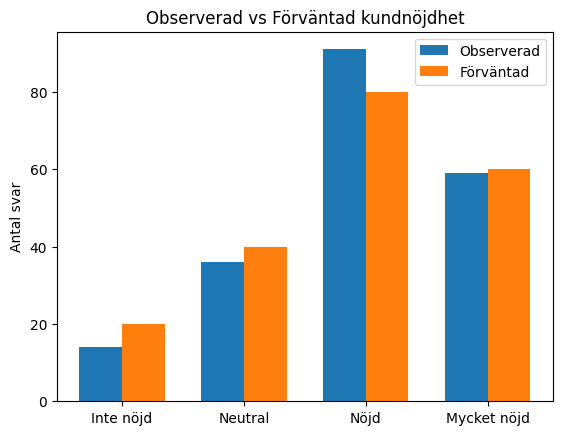

In [247]:
kategorier = ['Inte nöjd', 'Neutral', 'Nöjd', 'Mycket nöjd']

observed = [14, 36, 91, 59]
expected = [20, 40, 80, 60]

x = np.arange(len(kategorier))
width = 0.35

plt.figure()
plt.bar(x - width/2, observed, width, label='Observerad')
plt.bar(x + width/2, expected, width, label='Förväntad')

plt.xticks(x, kategorier)
plt.ylabel('Antal svar')
plt.title('Observerad vs Förväntad kundnöjdhet')
plt.legend()

plt.show()

Diagrammet visar att de observerade värdena ligger nära de förväntade värdena i alla kategorier.

Skillnaderna är relativt små, vilket stämmer överens med resultatet från Chi2-testet där ingen statistiskt signifikant skillnad kunde påvisas.

Detta stärker slutsatsen att kundnöjdheten följer branschstandarden.

---
# Uppgift 10 – Diagnostisk precision med Fishers exakta test

In [248]:
# STEG 1: Generera gruppspecifikt dataset
gruppnummer = 15
rng = np.random.default_rng(gruppnummer)

ai_success_rate     = 0.7 + (gruppnummer % 4) * 0.05   # = 0.85
manual_success_rate = 0.4 + (gruppnummer % 3) * 0.05   # = 0.40

ai_group     = rng.binomial(n=1, p=ai_success_rate,     size=12)
manual_group = rng.binomial(n=1, p=manual_success_rate, size=12)

ai_korrekt     = np.sum(ai_group)
ai_fel         = 12 - ai_korrekt
manual_korrekt = np.sum(manual_group)
manual_fel     = 12 - manual_korrekt

tabell = np.array([[ai_korrekt, ai_fel],
                   [manual_korrekt, manual_fel]])

data_df = pd.DataFrame(tabell,
                       index=['AI-verktyg', 'Manuell metod'],
                       columns=['Korrekt diagnos', 'Felaktig diagnos'])

print(f"Kontingenstabell för grupp {gruppnummer}:")
print(data_df)

Kontingenstabell för grupp 15:
               Korrekt diagnos  Felaktig diagnos
AI-verktyg                  11                 1
Manuell metod                5                 7


Fishers exakta test används istället för ett Chi2-test eftersom datamängden är liten och vissa celler i kontingenstabellen kan ha låga förväntade frekvenser.

Chi2-testet kräver större urval för att ge tillförlitliga resultat, medan Fishers test är mer exakt vid små sample.

Därför är Fishers test mer lämpligt i detta fall.

## Deluppgift 1: Teoretisk motivering – Varför Fishers exakta test?

Vi använder Fishers exakta test istället för Chi²-test av följande skäl:

Chi²-testet är en approximation som kräver att de förväntade cellfrekvenserna är minst 5 i alla celler. Med totalt 24 patienter fördelade på en 2×2-tabell riskerar flera celler att ha förväntade frekvenser under 5, vilket gör Chi²-approximationen opålitlig.

Fishers exakta test beräknar exakt sannolikhet utan approximation, vilket gör det idealt för små stickprov.

In [249]:
# Visa förväntade frekvenser för att motivera valet
n = tabell.sum()
rad_summor = tabell.sum(axis=1)
kol_summor = tabell.sum(axis=0)
print("Förväntade frekvenser (rad_summa × kol_summa / n):")
for i, rad in enumerate(['AI-verktyg', 'Manuell metod']):
    for j, kol in enumerate(['Korrekt diagnos', 'Felaktig diagnos']):
        förväntat = (rad_summor[i] * kol_summor[j]) / n
        print(f"  {rad} / {kol}: {förväntat:.2f}")
print()
print("Celler med förväntad frekvens < 5 gör Chi²-testet opålitligt => Fishers exakta test används.")

Förväntade frekvenser (rad_summa × kol_summa / n):
  AI-verktyg / Korrekt diagnos: 8.00
  AI-verktyg / Felaktig diagnos: 4.00
  Manuell metod / Korrekt diagnos: 8.00
  Manuell metod / Felaktig diagnos: 4.00

Celler med förväntad frekvens < 5 gör Chi²-testet opålitligt => Fishers exakta test används.


## Deluppgift 2: Hypotesformulering

In [250]:
print("Hypoteser:")
print("H0: Det finns inget samband mellan metod (AI vs. manuell) och diagnosprecision.")
print("AI-verktyget är inte bättre än manuell metod.")
print()
print("Ha: Det finns ett samband mellan metod och diagnosprecision.")
print("AI-verktyget ger en annorlunda (bättre) precisioner än manuell metod.")

Hypoteser:
H0: Det finns inget samband mellan metod (AI vs. manuell) och diagnosprecision.
AI-verktyget är inte bättre än manuell metod.

Ha: Det finns ett samband mellan metod och diagnosprecision.
AI-verktyget ger en annorlunda (bättre) precisioner än manuell metod.


## Deluppgift 3: Genomförande – Fishers exakta test

In [251]:
odds_ratio, p_fisher = stats.fisher_exact(tabell)

print(f"Fishers exakta test – resultat:")
print(f"  Odds Ratio : {odds_ratio:.4f}")
print(f"  p-värde    : {p_fisher:.4f}")

Fishers exakta test – resultat:
  Odds Ratio : 15.4000
  p-värde    : 0.0272


Resultatet från Fishers exakta test gav ett p-värde på 0.0272, vilket är mindre än signifikansnivån 0.05. Nollhypotesen förkastas därför.

Detta innebär att det finns ett statistiskt signifikant samband mellan metod och diagnosprecision.

Odds ratio är 15.4, vilket betyder att oddsen att ställa en korrekt diagnos är cirka 15 gånger högre med AI-verktyget jämfört med den manuella metoden.

Detta tyder på att AI-verktyget presterar betydligt bättre i detta dataset.

## Deluppgift 5: Analys och tolkning

In [252]:
alpha = 0.05
print(f"Signifikansnivå: alpha = {alpha}")
print(f"p-värde        : {p_fisher:.4f}")
print()

if p_fisher < alpha:
    print(f"Slutsats: p={p_fisher:.4f} < alpha={alpha} => Vi förkastar H0.")
    print("Det finns ett statistiskt signifikant samband mellan metod och diagnosprecision.")
    print("AI-verktyget ger signifikant bättre diagnostisk precision än manuell metod.")
else:
    print(f"Slutsats: p={p_fisher:.4f} >= alpha={alpha} => Vi kan inte förkasta H0.")
    print("Det finns inget statistiskt signifikant samband mellan metod och diagnosprecision.")

print()
print(f"Odds Ratio-tolkning:")
print(f"  OR = {odds_ratio:.2f} innebär att oddsen att få en korrekt diagnos är")
print(f"  {odds_ratio:.1f} gånger högre med AI-verktyget jämfört med manuell metod.")
if odds_ratio > 1:
    print(f"  Detta tyder på att AI-verktyget presterar avsevärt bättre i detta dataset.")

Signifikansnivå: alpha = 0.05
p-värde        : 0.0272

Slutsats: p=0.0272 < alpha=0.05 => Vi förkastar H0.
Det finns ett statistiskt signifikant samband mellan metod och diagnosprecision.
AI-verktyget ger signifikant bättre diagnostisk precision än manuell metod.

Odds Ratio-tolkning:
  OR = 15.40 innebär att oddsen att få en korrekt diagnos är
  15.4 gånger högre med AI-verktyget jämfört med manuell metod.
  Detta tyder på att AI-verktyget presterar avsevärt bättre i detta dataset.


In [253]:
import numpy as np

gruppnummer = 15
rng = np.random.default_rng(gruppnummer)

uppgifter = [8, 9, 10]
vald_uppgift = rng.choice(uppgifter)

print(f"Grupp {gruppnummer} ska redovisa uppgift {vald_uppgift}.")

Grupp 15 ska redovisa uppgift 10.
